=== METRICS ===
Total Revenue: 2297200.8603000003
Total Profit: 286397.0217
Margin: 12.467217240315604
Top State: California (457687.6315)
Top 5 states %: 51.97216982341211
Top Category: Technology
Most profitable product: Canon imageCLASS 2200 Advanced Copier
High Discount Loss Rate: 96.76956209619526
Error: 'numpy.ndarray' object is not callable


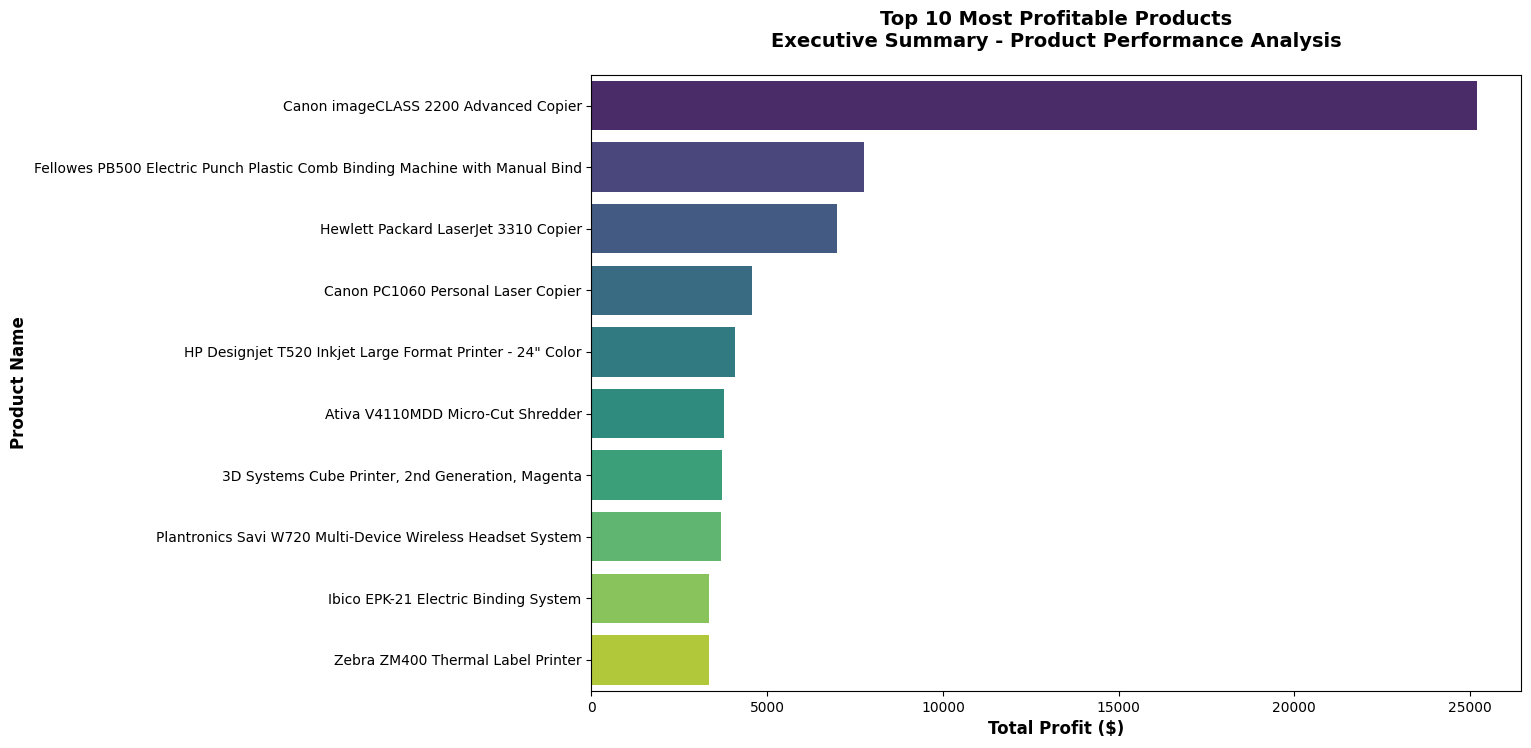

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

try:
    # Read dataset
    df = pd.read_csv("Sample - Superstore.csv", encoding='windows-1252')

    # 1. Cleaning & Preprocessing
    df.drop_duplicates(inplace=True)
    if 'Postal Code' in df.columns:
        df['Postal Code'] = df['Postal Code'].fillna(0)

    date_cols = ['Order Date', 'Ship Date']
    for col in date_cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], format='mixed', dayfirst=False)

    # Feature Engineering
    df['Profit Margin'] = (df['Profit'] / df['Sales']) * 100
    df['Order Year'] = df['Order Date'].dt.year
    df['Order Month'] = df['Order Date'].dt.month
    df['Order Month-Year'] = df['Order Date'].dt.to_period('M')

    # Calculate metrics for Executive Summary
    total_sales = df['Sales'].sum()
    total_profit = df['Profit'].sum()
    profit_margin = (total_profit / total_sales) * 100

    state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=True)
    top_state = state_sales.index[-1]
    top_state_sales = state_sales.iloc[-1]
    top_5_percent = (state_sales.tail(5).sum()/total_sales)*100

    top_category = df.groupby('Category')['Sales'].sum().sort_values(ascending=False).index[0]
    product_profit = df.groupby('Product Name')['Profit'].sum().sort_values(ascending=False)
    most_profitable_product = product_profit.index[0]

    high_discount_loss_rate = (df[df['Discount'] > 0.2]['Profit'] < 0).mean() * 100

    print("=== METRICS ===")
    print(f"Total Revenue: {total_sales}")
    print(f"Total Profit: {total_profit}")
    print(f"Margin: {profit_margin}")
    print(f"Top State: {top_state} ({top_state_sales})")
    print(f"Top 5 states %: {top_5_percent}")
    print(f"Top Category: {top_category}")
    print(f"Most profitable product: {most_profitable_product}")
    print(f"High Discount Loss Rate: {high_discount_loss_rate}")

    # 2. Time-Series Trend Analysis (Static snapshot for chat)
    plt.figure(figsize=(10, 5))
    total_monthly = df.groupby('Order Month-Year')['Sales'].sum()
    plt.plot(total_monthly.index.to_timestamp(), total_monthly.values, marker='o', linewidth=2, markersize=4)
    plt.title('Monthly Sales Trend - All Categories', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Sales ($)')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('timeseries.png')
    plt.close()

    # 3. Top 10 Most Profitable Products
    top_10_profit = product_profit.head(10)
    plt.figure(figsize=(12, 8))
    ax = sns.barplot(x=top_10_profit.values, y=top_10_profit.index, palette='viridis', orient='h')
    plt.title('Top 10 Most Profitable Products\nExecutive Summary - Product Performance Analysis', fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('Total Profit ($)', fontsize=12, fontweight='bold')
    plt.ylabel('Product Name', fontsize=12, fontweight='bold')
    for i, (product, profit) in enumerate(top_10_profit.items()):
        ax.text(profit + max(top_10_profit.values()) * 0.01, i, f'${profit:,.0f}', va='center', fontweight='bold', fontsize=10)
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('top10products.png')
    plt.close()

    # 4. Discount vs Profit Scatter Plot
    plt.figure(figsize=(12, 8))
    sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category', alpha=0.6, s=50)
    sns.regplot(data=df, x='Discount', y='Profit', scatter=False, color='red', line_kws={'linewidth': 2, 'linestyle': '--'})
    plt.title('Discount Strategy Analysis: Impact on Profitability by Category', fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('Discount Rate', fontsize=12, fontweight='bold')
    plt.ylabel('Profit ($)', fontsize=12, fontweight='bold')
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.3, linewidth=1)
    plt.text(0.5, 50, 'Break-even line', fontsize=10, alpha=0.7)
    plt.grid(True, alpha=0.3)
    plt.legend(title='Product Category', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig('discount_profit.png')
    plt.close()

    print("\nCharts generated successfully.")
except Exception as e:
    print(f"Error: {e}")

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("Sample - Superstore.csv", encoding='windows-1252')

df.drop_duplicates(inplace=True)
if 'Postal Code' in df.columns:
    df['Postal Code'] = df['Postal Code'].fillna(0)

date_cols = ['Order Date', 'Ship Date']
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], format='mixed', dayfirst=False)

df['Profit Margin'] = (df['Profit'] / df['Sales']) * 100
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Month-Year'] = df['Order Date'].dt.to_period('M')

# 3. Top 10 Most Profitable Products
product_profit = df.groupby('Product Name')['Profit'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 8))
ax = sns.barplot(x=product_profit.values, y=product_profit.index, palette='viridis', orient='h')
plt.title('Top 10 Most Profitable Products\nExecutive Summary - Product Performance Analysis', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Total Profit ($)', fontsize=12, fontweight='bold')
plt.ylabel('Product Name', fontsize=12, fontweight='bold')
# fix annotation
for i, v in enumerate(product_profit.values):
    ax.text(v + (max(product_profit.values) * 0.01), i, f'${v:,.0f}', va='center', fontweight='bold', fontsize=10)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('top10products.png')
plt.close()

# 4. Discount vs Profit Scatter Plot
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category', alpha=0.6, s=50)
sns.regplot(data=df, x='Discount', y='Profit', scatter=False, color='red', line_kws={'linewidth': 2, 'linestyle': '--'})
plt.title('Discount Strategy Analysis: Impact on Profitability by Category', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Discount Rate', fontsize=12, fontweight='bold')
plt.ylabel('Profit ($)', fontsize=12, fontweight='bold')
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3, linewidth=1)
plt.text(0.5, 50, 'Break-even line', fontsize=10, alpha=0.7)
plt.grid(True, alpha=0.3)
plt.legend(title='Product Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('discount_profit.png')
plt.close()

state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=True)

# Advanced Dashboard (Optional Challenge)
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

total_monthly = df.groupby('Order Month-Year')['Sales'].sum()
ax1.plot(total_monthly.index.to_timestamp(), total_monthly.values, marker='o')
ax1.set_title('Monthly Sales Trend')
ax1.tick_params(axis='x', rotation=45)

category_sales = df.groupby('Category')['Sales'].sum()
ax2.bar(category_sales.index, category_sales.values)
ax2.set_title('Sales by Category')

top_10_states = state_sales.tail(10)
ax3.barh(range(len(top_10_states)), top_10_states.values)
ax3.set_yticks(range(len(top_10_states)))
ax3.set_yticklabels(top_10_states.index)
ax3.set_title('Top 10 States by Sales')

for category in df['Category'].unique():
    cat_data = df[df['Category'] == category]
    ax4.scatter(cat_data['Discount'], cat_data['Profit'], label=category, alpha=0.6)
ax4.set_xlabel('Discount')
ax4.set_ylabel('Profit')
ax4.set_title('Discount vs Profit by Category')
ax4.legend()
ax4.axhline(y=0, color='black', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('dashboard.png')
plt.close()

print("Charts successfully regenerated.")

Charts successfully regenerated.
